1 ЭТАП.

In [2]:
%pip install -q \
    numpy \
    pandas \
    matplotlib \
    scikit-learn \
    sentence-transformers \
    faiss-cpu \
    psutil \
    ijson \
    tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import time
from pathlib import Path

import ijson
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

from tqdm.auto import tqdm
from IPython.display import display

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 30)

print("Все библиотеки импортированы")

Все библиотеки импортированы


/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
PROJECT_DIR = Path("/home/ubuntu/nlp_s3_project")

ARTICLES_PATH = PROJECT_DIR / "arxiv-metadata-s.json"
TEST_PATH = PROJECT_DIR / "test_sample.csv"

CACHE_PATH = PROJECT_DIR / "articles_reduced.pkl"

if not PROJECT_DIR.exists():
    raise FileNotFoundError(
        f"Папка проекта не найдена: {PROJECT_DIR}"
    )

if not ARTICLES_PATH.exists():
    raise FileNotFoundError(
        f"Файл статей не найден: {ARTICLES_PATH}"
    )

if not TEST_PATH.exists():
    raise FileNotFoundError(
        f"Тестовый файл не найден: {TEST_PATH}"
    )

print("Папка проекта:", PROJECT_DIR)
print("Файл статей:", ARTICLES_PATH)
print("Тестовый файл:", TEST_PATH)

print(
    "\nРазмер файла статей:",
    round(ARTICLES_PATH.stat().st_size / 1024**2, 2),
    "MB"
)

print(
    "Размер тестового файла:",
    round(TEST_PATH.stat().st_size / 1024**2, 2),
    "MB"
)

Папка проекта: /home/ubuntu/nlp_s3_project
Файл статей: /home/ubuntu/nlp_s3_project/arxiv-metadata-s.json
Тестовый файл: /home/ubuntu/nlp_s3_project/test_sample.csv

Размер файла статей: 220.91 MB
Размер тестового файла: 1.09 MB


In [5]:
def clean_text(value):
    if value is None:
        return ""

    return " ".join(str(value).split())


if CACHE_PATH.exists():
    print("Загружаем готовый облегчённый датасет...")

    articles_df = pd.read_pickle(CACHE_PATH)

else:
    print("Читаем исходный JSON...")

    articles = []

    for article in tqdm(
        iterate_articles(ARTICLES_PATH, json_format),
        desc="Загрузка статей"
    ):
        article_id = clean_text(article.get("id"))

        if not article_id:
            continue

        articles.append(
            {
                "id": article_id,
                "title": clean_text(article.get("title")),
                "abstract": clean_text(article.get("abstract")),
                "categories": clean_text(
                    article.get("categories")
                ),
                "update_date": clean_text(
                    article.get("update_date")
                )
            }
        )

    articles_df = pd.DataFrame(articles)

    articles_df.to_pickle(CACHE_PATH)

    print("Облегчённый датасет сохранён:")
    print(CACHE_PATH)

print("\nКоличество статей:", len(articles_df))
print("Размер таблицы:", articles_df.shape)

display(articles_df.head(3))

Загружаем готовый облегчённый датасет...

Количество статей: 98213
Размер таблицы: (98213, 5)


,id,title,abstract,categories,update_date
0,0704.0038,The discrete dipole approximation: an overview and recent developments,"We present a review of the discrete dipole approximation (DDA), which is a general method to simulate light scattering by arbitrarily shaped particles. We put the method in historical context and ...",physics.optics physics.comp-ph,2022-03-30
1,0704.0057,High-spin to low-spin and orbital polarization transitions in multiorbital Mott systems,We study the interplay of crystal field splitting and Hund coupling in a two-orbital model which captures the essential physics of systems with two electrons or holes in the e_g shell. We use sing...,cond-mat.str-el,2009-11-13
2,0704.0060,Coulomb excitation of unstable nuclei at intermediate energies,We investigate the Coulomb excitation of low-lying states of unstable nuclei in intermediate energy collisions ($E_{lab}\sim10-500$ MeV/nucleon). It is shown that the cross sections for the $E1$ a...,nucl-th,2008-11-26


In [6]:
test_df = pd.read_csv(
    TEST_PATH,
    dtype={"id": str}
)

test_df.columns = test_df.columns.str.strip()

for column in ["id", "query", "abstract"]:
    if column in test_df.columns:
        test_df[column] = (
            test_df[column]
            .fillna("")
            .astype(str)
            .str.strip()
        )

print("Количество тестовых запросов:", len(test_df))
print("Размер тестовой таблицы:", test_df.shape)
print("Колонки:", test_df.columns.tolist())

display(test_df.head(5))

Количество тестовых запросов: 1000
Размер тестовой таблицы: (1000, 3)
Колонки: ['id', 'abstract', 'query']


,id,abstract,query
0,2412.16732,"A new platinate was recently discovered when Nd2O3 was explored as a platinum\ncapture material in the Ostwald process, formed by a direct reaction between\nPtO2(g) and Nd2O3. The crystal structur...",What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under thermal conditions?
1,nucl-th/9602019,The production cross sections of various fragments from proton-induced\nreactions on $^{56}$Fe and $^{27}$Al have been analyzed by the Quantum\nMolecular Dynamics (QMD) plus Statistical Decay Mode...,How does the inclusion of statistical decay affect the shape of mass and charge distributions in quantum molecular dynamics simulations?
2,2501.05500,"This survey provides a comprehensive examination of verifiable computing,\ntracing its evolution from foundational complexity theory to modern\nzero-knowledge succinct non-interactive arguments of...",What are the core components of modern zero-knowledge proofs discussed in the context of verifiable computing?
3,2506.20892,A critical challenge for operating fusion burning plasma in high confinement mode lies in mitigating damage caused by edge localized modes (ELMs). While impurity seeding has been experimentally va...,How does impurity seeding affect the timing and magnitude of energy loss during ELM crashes?
4,2208.02031,"In this work, we present the first corpus for German Adverse Drug Reaction\n(ADR) detection in patient-generated content. The data consists of 4,169 binary\nannotated documents from a German patie...",What is the primary challenge of the newly developed German ADR detection corpus in terms of its annotation?


In [7]:
print("ДАТАСЕТ СТАТЕЙ")
print("-" * 40)

print("Количество строк:", len(articles_df))
print("Количество колонок:", len(articles_df.columns))
print("Колонки:", articles_df.columns.tolist())

print("\nТипы данных:")
print(articles_df.dtypes)

print("\nПропуски:")
print(articles_df.isna().sum())


print("\n\nТЕСТОВЫЙ ДАТАСЕТ")
print("-" * 40)

print("Количество строк:", len(test_df))
print("Количество колонок:", len(test_df.columns))
print("Колонки:", test_df.columns.tolist())

print("\nПропуски:")
print(test_df.isna().sum())

ДАТАСЕТ СТАТЕЙ
----------------------------------------
Количество строк: 98213
Количество колонок: 5
Колонки: ['id', 'title', 'abstract', 'categories', 'update_date']

Типы данных:
id             object
title          object
abstract       object
categories     object
update_date    object
dtype: object

Пропуски:
id             0
title          0
abstract       0
categories     0
update_date    0
dtype: int64


ТЕСТОВЫЙ ДАТАСЕТ
----------------------------------------
Количество строк: 1000
Количество колонок: 3
Колонки: ['id', 'abstract', 'query']

Пропуски:
id          0
abstract    0
query       0
dtype: int64


In [8]:
print("Пустые названия статей:")
print((articles_df["title"].str.len() == 0).sum())

print("\nПустые аннотации:")
print((articles_df["abstract"].str.len() == 0).sum())

print("\nПустые категории:")
print((articles_df["categories"].str.len() == 0).sum())

print("\nПустые тестовые запросы:")
print((test_df["query"].str.len() == 0).sum())

Пустые названия статей:
0

Пустые аннотации:
0

Пустые категории:
0

Пустые тестовые запросы:
0


In [9]:
print(
    "Повторяющиеся ID статей:",
    articles_df["id"].duplicated().sum()
)

print(
    "Полностью одинаковые статьи:",
    articles_df.duplicated().sum()
)

print(
    "Повторяющиеся тестовые запросы:",
    test_df["query"].duplicated().sum()
)

print(
    "Повторяющиеся правильные ID в тесте:",
    test_df["id"].duplicated().sum()
)

Повторяющиеся ID статей: 0


Полностью одинаковые статьи: 0
Повторяющиеся тестовые запросы: 0
Повторяющиеся правильные ID в тесте: 0


In [10]:
article_ids = set(articles_df["id"])

test_df["id_exists"] = test_df["id"].isin(article_ids)

found_count = int(test_df["id_exists"].sum())
total_count = len(test_df)
coverage = test_df["id_exists"].mean()

print(
    "Правильных статей найдено в базе:",
    found_count,
    "из",
    total_count
)

print(
    "Доля найденных правильных статей:",
    round(coverage, 4)
)

Правильных статей найдено в базе: 1000 из 1000
Доля найденных правильных статей: 1.0


Статистика длины аннотаций:


,Количество слов
count,98213.000000
mean,143.849450
std,63.217779
min,2.000000
50%,140.000000
75%,188.000000
95%,256.000000
99%,288.000000
max,584.000000


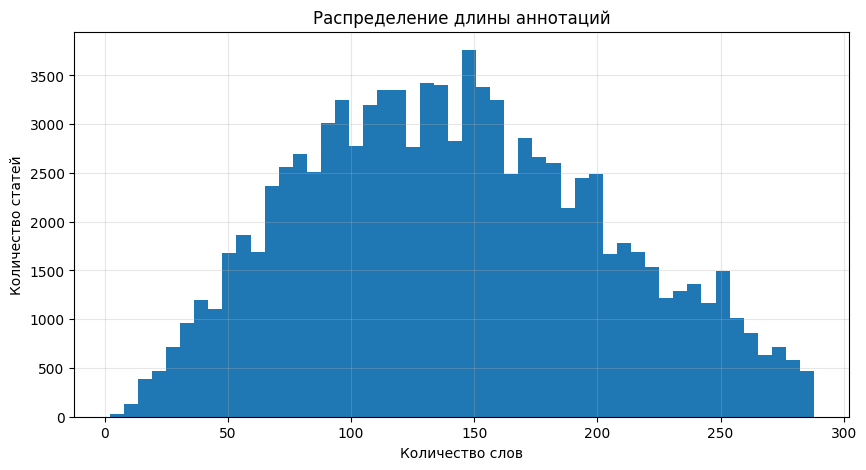

In [11]:
articles_df["search_text"] = (
    articles_df["title"].fillna("")
    + ". "
    + articles_df["abstract"].fillna("")
)

articles_df["abstract_word_count"] = (
    articles_df["abstract"]
    .str.split()
    .str.len()
    .fillna(0)
    .astype(int)
)

print("Статистика длины аннотаций:")

display(
    articles_df["abstract_word_count"].describe(
        percentiles=[0.5, 0.75, 0.95, 0.99]
    ).to_frame("Количество слов")
)

plot_limit = int(
    articles_df["abstract_word_count"].quantile(0.99)
)

plt.figure(figsize=(10, 5))

articles_df.loc[
    articles_df["abstract_word_count"] <= plot_limit,
    "abstract_word_count"
].hist(
    bins=50
)

plt.title("Распределение длины аннотаций")
plt.xlabel("Количество слов")
plt.ylabel("Количество статей")
plt.grid(alpha=0.3)
plt.show()

Количество уникальных категорий: 174


,Количество статей
categories,
cs.LG,8152
hep-ph,6692
hep-th,6111
quant-ph,5783
cs.CV,5668
cs.AI,4842
gr-qc,4096
astro-ph,3754
cond-mat.mtrl-sci,3634


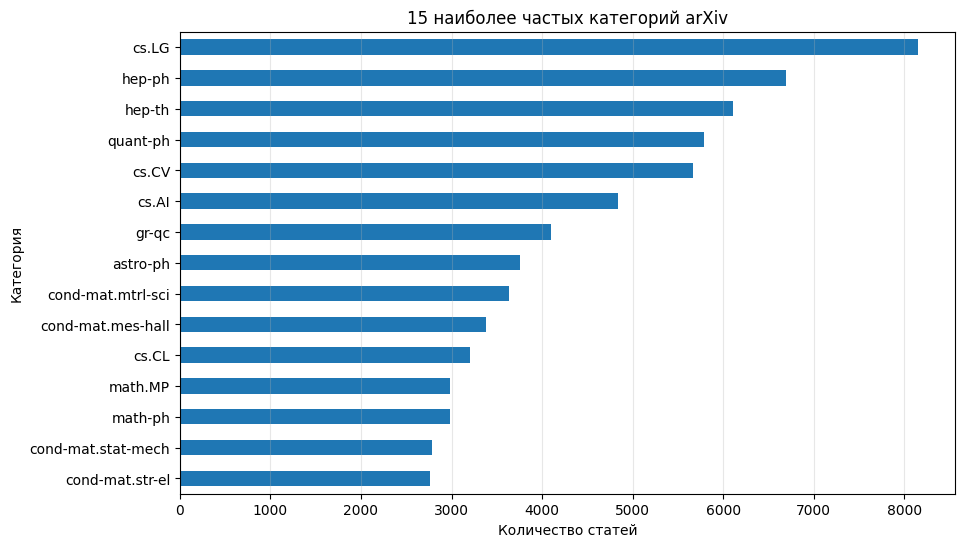

In [12]:
category_counts = (
    articles_df["categories"]
    .fillna("")
    .str.split()
    .explode()
)

category_counts = category_counts[
    category_counts.str.len() > 0
].value_counts()

print(
    "Количество уникальных категорий:",
    len(category_counts)
)

display(
    category_counts.head(15).to_frame(
        "Количество статей"
    )
)

plt.figure(figsize=(10, 6))

category_counts.head(15).sort_values().plot(
    kind="barh"
)

plt.title("15 наиболее частых категорий arXiv")
plt.xlabel("Количество статей")
plt.ylabel("Категория")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [13]:
test_examples = test_df.merge(
    articles_df[
        [
            "id",
            "title",
            "categories"
        ]
    ],
    on="id",
    how="left"
)

print("Размер поисковой базы:", len(articles_df))
print("Количество тестовых запросов:", len(test_df))

display(
    test_examples[
        [
            "query",
            "id",
            "title",
            "categories"
        ]
    ].head(10)
)

Размер поисковой базы: 98213
Количество тестовых запросов: 1000


,query,id,title,categories
0,What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under thermal conditions?,2412.16732,"Crystal structure of Nd10.67Pt4O24, a new neodymium platinate",cond-mat.mtrl-sci
1,How does the inclusion of statistical decay affect the shape of mass and charge distributions in quantum molecular dynamics simulations?,nucl-th/9602019,Analysis of proton-induced fragment production cross sections by the Quantum Molecular Dynamics plus Statistical Decay Model,nucl-th
2,What are the core components of modern zero-knowledge proofs discussed in the context of verifiable computing?,2501.05500,A Survey of Interactive Verifiable Computing: Utilizing Low-degree Polynomials,cs.LO cs.CR
3,How does impurity seeding affect the timing and magnitude of energy loss during ELM crashes?,2506.20892,Nonlinear edge localized mode with impurity seeding in CFETR hybrid scenario,physics.plasm-ph
4,What is the primary challenge of the newly developed German ADR detection corpus in terms of its annotation?,2208.02031,Cross-lingual Approaches for the Detection of Adverse Drug Reactions in German from a Patient's Perspective,cs.CL cs.LG
5,Can complex potentials serve as both refractive and absorptive optical devices without altering the energy spectrum?,0902.4052,Optical potentials using resonance states in Supersymmetric Quantum Mechanics,math-ph hep-th math.MP quant-ph
6,What properties does the set $A_\mu$ exhibit under various conditions related to the amenability of a group $G$?,1605.04065,On a theorem of Avez,math.GR math.PR
7,How does the CSDW module improve change detection in deep learning by leveraging both spatial and channel differences?,2501.10905,A Remote Sensing Image Change Detection Method Integrating Layer Exchange and Channel-Spatial Differences,cs.CV
8,What is the advantage of using the new algorithm for Brauer-Manin obstructions compared to traditional descent-based methods?,2112.00230,Brauer-Manin obstructions on hyperelliptic curves,math.NT
9,What are the necessary conditions for ensuring the existence of a Lipschitz continuous solution to a master equation with common noise on a finite state space?,2402.05635,Noise through an additional variable for mean field games master equation on finite state space,math.AP


Вывод по этапу 1

В датасете содержится около 98 тысяч статей arXiv и 1000 тестовых запросов. Для поиска будет использоваться объединение названия и аннотации статьи.

Сначала будет реализован базовый поиск TF-IDF, затем семантический поиск с помощью эмбеддингов и FAISS. Качество системы будет оцениваться метрикой MRR, а скорость отдельных компонентов — с помощью профилирования.

Основные ограничения системы: размер базы, время вычисления эмбеддингов и использование памяти.


2 ЭТАП.

In [14]:
import time

import faiss
import torch
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer

EMBEDDINGS_PATH = PROJECT_DIR / "article_embeddings.npy"
FAISS_INDEX_PATH = PROJECT_DIR / "articles_faiss.index"

print("Импорты выполнены")

Импорты выполнены


In [15]:
if "search_text" not in articles_df.columns:
    articles_df["search_text"] = (
        articles_df["title"].fillna("")
        + ". "
        + articles_df["abstract"].fillna("")
    )

retrieval_df = (
    articles_df[
        [
            "id",
            "title",
            "abstract",
            "categories",
            "search_text"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

retrieval_df["search_text"] = (
    retrieval_df["search_text"]
    .fillna("")
    .astype(str)
)

print("Размер поисковой базы:", len(retrieval_df), "статей")
display(retrieval_df.head(3))

Размер поисковой базы: 98213 статей


,id,title,abstract,categories,search_text
0,0704.0038,The discrete dipole approximation: an overview and recent developments,"We present a review of the discrete dipole approximation (DDA), which is a general method to simulate light scattering by arbitrarily shaped particles. We put the method in historical context and ...",physics.optics physics.comp-ph,"The discrete dipole approximation: an overview and recent developments. We present a review of the discrete dipole approximation (DDA), which is a general method to simulate light scattering by ar..."
1,0704.0057,High-spin to low-spin and orbital polarization transitions in multiorbital Mott systems,We study the interplay of crystal field splitting and Hund coupling in a two-orbital model which captures the essential physics of systems with two electrons or holes in the e_g shell. We use sing...,cond-mat.str-el,High-spin to low-spin and orbital polarization transitions in multiorbital Mott systems. We study the interplay of crystal field splitting and Hund coupling in a two-orbital model which captures t...
2,0704.0060,Coulomb excitation of unstable nuclei at intermediate energies,We investigate the Coulomb excitation of low-lying states of unstable nuclei in intermediate energy collisions ($E_{lab}\sim10-500$ MeV/nucleon). It is shown that the cross sections for the $E1$ a...,nucl-th,Coulomb excitation of unstable nuclei at intermediate energies. We investigate the Coulomb excitation of low-lying states of unstable nuclei in intermediate energy collisions ($E_{lab}\sim10-500$ ...


In [16]:
MODEL_NAME = "sentence-transformers/multi-qa-MiniLM-L6-cos-v1"

device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = SentenceTransformer(
    MODEL_NAME,
    device=device
)

embedding_model.max_seq_length = 256

print("Модель:", MODEL_NAME)
print("Устройство:", device)
print(
    "Размерность вектора:",
    embedding_model.get_sentence_embedding_dimension()
)

Модель: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
Устройство: cuda
Размерность вектора: 384


/tmp/ipykernel_55283/4236705086.py:16: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_model.get_sentence_embedding_dimension()


In [17]:
need_create_embeddings = True

if EMBEDDINGS_PATH.exists():
    article_embeddings = np.load(
        EMBEDDINGS_PATH,
        mmap_mode="r"
    )

    if len(article_embeddings) == len(retrieval_df):
        need_create_embeddings = False
        print("Загружаем готовые эмбеддинги")
    else:
        print("Размер сохранённых эмбеддингов не совпадает с базой")


if need_create_embeddings:
    article_embeddings = embedding_model.encode(
        retrieval_df["search_text"].tolist(),
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    article_embeddings = article_embeddings.astype(
        "float32"
    )

    np.save(
        EMBEDDINGS_PATH,
        article_embeddings
    )

    print("Эмбеддинги сохранены:", EMBEDDINGS_PATH)


article_embeddings = np.asarray(
    article_embeddings,
    dtype="float32"
)

print("Форма эмбеддингов:", article_embeddings.shape)

Загружаем готовые эмбеддинги
Форма эмбеддингов: (98213, 384)


In [18]:
embedding_dimension = article_embeddings.shape[1]

if FAISS_INDEX_PATH.exists():
    faiss_index = faiss.read_index(
        str(FAISS_INDEX_PATH)
    )

    if faiss_index.ntotal != len(retrieval_df):
        print("Старый индекс не подходит, создаём новый")

        faiss_index = faiss.IndexFlatIP(
            embedding_dimension
        )

        faiss_index.add(article_embeddings)

        faiss.write_index(
            faiss_index,
            str(FAISS_INDEX_PATH)
        )

else:
    faiss_index = faiss.IndexFlatIP(
        embedding_dimension
    )

    faiss_index.add(article_embeddings)

    faiss.write_index(
        faiss_index,
        str(FAISS_INDEX_PATH)
    )


print("Количество статей в индексе:", faiss_index.ntotal)
print("Размерность векторов:", faiss_index.d)

Количество статей в индексе: 98213
Размерность векторов: 384


In [19]:
def synchronize_gpu():
    if device == "cuda":
        torch.cuda.synchronize()


def search_articles(query, top_k=5):
    query = str(query).strip()

    if not query:
        raise ValueError("Запрос не должен быть пустым")

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    scores, positions = faiss_index.search(
        query_embedding,
        top_k
    )

    results = retrieval_df.iloc[
        positions[0]
    ].copy()

    results.insert(
        0,
        "score",
        scores[0]
    )

    results.insert(
        0,
        "rank",
        range(1, len(results) + 1)
    )

    return results.reset_index(drop=True)


def profile_search(query, top_k=5):
    profile = {}

    synchronize_gpu()
    total_start = time.perf_counter()

    encode_start = time.perf_counter()

    query_embedding = embedding_model.encode(
        [str(query)],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    synchronize_gpu()

    profile["encoding_time"] = (
        time.perf_counter() - encode_start
    )

    search_start = time.perf_counter()

    scores, positions = faiss_index.search(
        query_embedding,
        top_k
    )

    profile["faiss_time"] = (
        time.perf_counter() - search_start
    )

    formatting_start = time.perf_counter()

    results = retrieval_df.iloc[
        positions[0]
    ].copy()

    results.insert(0, "score", scores[0])
    results.insert(
        0,
        "rank",
        range(1, len(results) + 1)
    )

    results = results.reset_index(drop=True)

    profile["formatting_time"] = (
        time.perf_counter() - formatting_start
    )

    profile["total_time"] = (
        time.perf_counter() - total_start
    )

    return results, profile


print("Функции поиска созданы")

Функции поиска созданы


In [20]:
def reciprocal_rank(retrieved_ids, relevant_id):
    relevant_id = str(relevant_id)

    for rank, article_id in enumerate(
        retrieved_ids,
        start=1
    ):
        if str(article_id) == relevant_id:
            return 1.0 / rank

    return 0.0


def mean_reciprocal_rank(
    retrieved_ids_list,
    relevant_ids
):
    scores = [
        reciprocal_rank(retrieved_ids, relevant_id)
        for retrieved_ids, relevant_id
        in zip(retrieved_ids_list, relevant_ids)
    ]

    return float(np.mean(scores))


example_query = test_df.iloc[0]["query"]
correct_id = test_df.iloc[0]["id"]

results, profile = profile_search(
    example_query,
    top_k=10
)

rr = reciprocal_rank(
    results["id"].tolist(),
    correct_id
)

print("Запрос:")
print(example_query)

print("\nПравильный ID:", correct_id)
print("Reciprocal Rank:", rr)

print("\nПрофиль времени:")
for component, seconds in profile.items():
    print(f"{component}: {seconds:.6f} сек.")

display(
    results[
        [
            "rank",
            "score",
            "id",
            "title",
            "categories"
        ]
    ]
)

Запрос:
What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under thermal conditions?

Правильный ID: 2412.16732
Reciprocal Rank: 1.0

Профиль времени:
encoding_time: 0.154828 сек.
faiss_time: 0.011529 сек.
formatting_time: 0.001409 сек.
total_time: 0.167774 сек.


,rank,score,id,title,categories
0,1,0.583267,2412.16732,"Crystal structure of Nd10.67Pt4O24, a new neodymium platinate",cond-mat.mtrl-sci
1,2,0.527276,1810.01954,Homogeneous Nucleation and Forest Hardening Result in Thermal Hardening Phenomenon in Shock Loaded BCC Metals,cond-mat.mtrl-sci cond-mat.other
2,3,0.525748,2109.04710,High and anomalous thermal conductivity in monolayer MSi$_2$Z$_4$ semiconductors,cond-mat.mtrl-sci
3,4,0.525625,2302.11541,Temperature effects on the point defects formation in [111] W by neutron induced collision cascade,physics.comp-ph cond-mat.mtrl-sci
4,5,0.523499,1906.03084,Non-thermal desorption of complex organic molecules,astro-ph.GA
5,6,0.523417,1405.2422,Common origin of exotic properties in ceramic and hybrid negative thermal expansion materials,cond-mat.mtrl-sci
6,7,0.518413,1903.08862,High thermal conductivity of high-quality monolayer boron nitride and its thermal expansion,cond-mat.mtrl-sci
7,8,0.517753,cond-mat/0205303,Temperature Evolution of Sodium Nitrite Structure in a Restricted Geometry,cond-mat.mtrl-sci
8,9,0.511579,1110.1603,Collective Thermotaxis of Thermally Active Colloids,cond-mat.soft cond-mat.stat-mech physics.flu-dyn
9,10,0.509535,2507.17040,A Novel Discovery of Negative Thermal Expansion in Rare-earth Pyrochlore through Anion Order-Disorder Transition,cond-mat.mtrl-sci


Вывод по этапу 2

Retrieval-система успешно обработала тестовый запрос и поставила правильную статью с ID 2412.16732 на первое место. Поэтому Reciprocal Rank для этого примера равен 1.0.

 Больше всего времени заняло создание эмбеддинга запроса, тогда как поиск в FAISS и формирование результатов выполнялись значительно быстрее. Система корректно возвращает релевантные статьи вместе с их ID, названием, категорией и оценкой похожести.

3 ЭТАП

In [21]:
import time
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.auto import tqdm
from IPython.display import display


TOP_K = 5
CANDIDATE_K = 100

TFIDF_MODEL_PATH = PROJECT_DIR / "tfidf_vectorizer.joblib"
TFIDF_MATRIX_PATH = PROJECT_DIR / "tfidf_matrix.npz"
RESULTS_PATH = PROJECT_DIR / "evaluation_results_mrr5.csv"

print("Оцениваем метрику MRR@5")
print("Размер базы:", len(retrieval_df), "статей")
print("Количество запросов:", len(test_df))

Оцениваем метрику MRR@5
Размер базы: 98213 статей
Количество запросов: 1000


In [22]:
# Увеличиваем вес названия статьи,
# поэтому добавляем его два раза
lexical_texts = (
    retrieval_df["title"].fillna("")
    + " "
    + retrieval_df["title"].fillna("")
    + " "
    + retrieval_df["abstract"].fillna("")
).tolist()


need_build_tfidf = True

if TFIDF_MODEL_PATH.exists() and TFIDF_MATRIX_PATH.exists():
    tfidf_vectorizer = joblib.load(TFIDF_MODEL_PATH)
    tfidf_matrix = sparse.load_npz(TFIDF_MATRIX_PATH)

    if tfidf_matrix.shape[0] == len(retrieval_df):
        need_build_tfidf = False
        print("Готовый TF-IDF индекс загружен")
    else:
        print("Сохранённый индекс не совпадает с базой")


if need_build_tfidf:
    print("Создаём TF-IDF индекс...")

    tfidf_vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=200_000,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32
    )

    tfidf_matrix = tfidf_vectorizer.fit_transform(
        lexical_texts
    )

    joblib.dump(
        tfidf_vectorizer,
        TFIDF_MODEL_PATH
    )

    sparse.save_npz(
        TFIDF_MATRIX_PATH,
        tfidf_matrix
    )

    print("TF-IDF индекс сохранён")


print("Размер TF-IDF матрицы:", tfidf_matrix.shape)

Готовый TF-IDF индекс загружен
Размер TF-IDF матрицы: (98213, 200000)


In [23]:
def profile_hybrid_search(
    query,
    top_k=5,
    candidate_k=100,
    rrf_constant=60,
    dense_weight=1.0,
    lexical_weight=1.3
):
    query = str(query).strip()

    if not query:
        raise ValueError("Запрос не должен быть пустым")

    profile = {}

    synchronize_gpu()
    total_start = time.perf_counter()

  
    start = time.perf_counter()

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    synchronize_gpu()

    profile["encoding_time"] = (
        time.perf_counter() - start
    )


    start = time.perf_counter()

    current_candidate_k = min(
        candidate_k,
        len(retrieval_df)
    )

    dense_scores, dense_positions = faiss_index.search(
        query_embedding,
        current_candidate_k
    )

    profile["faiss_time"] = (
        time.perf_counter() - start
    )

  
    start = time.perf_counter()

    query_tfidf = tfidf_vectorizer.transform(
        [query]
    )

    lexical_scores = (
        tfidf_matrix @ query_tfidf.T
    ).toarray().ravel()

    lexical_positions = np.argpartition(
        -lexical_scores,
        current_candidate_k - 1
    )[:current_candidate_k]

    lexical_positions = lexical_positions[
        np.argsort(
            lexical_scores[lexical_positions]
        )[::-1]
    ]

    profile["tfidf_time"] = (
        time.perf_counter() - start
    )


    start = time.perf_counter()

    combined_scores = {}

    for rank, position in enumerate(
        dense_positions[0],
        start=1
    ):
        position = int(position)

        combined_scores[position] = (
            combined_scores.get(position, 0.0)
            + dense_weight / (rrf_constant + rank)
        )

    for rank, position in enumerate(
        lexical_positions,
        start=1
    ):
        position = int(position)

        combined_scores[position] = (
            combined_scores.get(position, 0.0)
            + lexical_weight / (rrf_constant + rank)
        )

    best_positions = sorted(
        combined_scores,
        key=combined_scores.get,
        reverse=True
    )[:top_k]

    profile["fusion_time"] = (
        time.perf_counter() - start
    )


    start = time.perf_counter()

    results = retrieval_df.iloc[
        best_positions
    ].copy()

    results.insert(
        0,
        "score",
        [
            combined_scores[position]
            for position in best_positions
        ]
    )

    results.insert(
        0,
        "rank",
        range(1, len(results) + 1)
    )

    results = results.reset_index(drop=True)

    profile["formatting_time"] = (
        time.perf_counter() - start
    )

    profile["total_time"] = (
        time.perf_counter() - total_start
    )

    return results, profile


print("Гибридный поиск создан")

Гибридный поиск создан


In [24]:
example_query = test_df.iloc[0]["query"]
correct_id = str(test_df.iloc[0]["id"])

example_results, example_profile = profile_hybrid_search(
    example_query,
    top_k=TOP_K,
    candidate_k=CANDIDATE_K
)

example_rank = next(
    (
        rank
        for rank, found_id in enumerate(
            example_results["id"].astype(str),
            start=1
        )
        if found_id == correct_id
    ),
    0
)

print("Запрос:")
print(example_query)

print("\nПравильный ID:", correct_id)
print("Позиция правильной статьи:", example_rank)

display(
    example_results[
        [
            "rank",
            "score",
            "id",
            "title",
            "categories"
        ]
    ]
)

Запрос:
What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under thermal conditions?

Правильный ID: 2412.16732
Позиция правильной статьи: 0


,rank,score,id,title,categories
0,1,0.021311,astro-ph/9804186,"ROSAT archival observations of 1SAX J0054.9-7226 = 2E 0053.2-7242, a newly discovered X-ray pulsar in the SMC",astro-ph
1,2,0.021193,cond-mat/0103435,Experimental study of MgB2 decomposition,cond-mat.supr-con
2,3,0.020968,1310.1397,The role of interference in unraveling the ZZ-couplings of the newly discovered boson at the LHC,hep-ph hep-ex
3,4,0.020635,1205.0719,A newly discovered VHE gamma-ray PWN candidate around PSR J1459-60,astro-ph.HE
4,5,0.020313,astro-ph/0503158,Radial Velocities of Newly Discovered Globular Clusters in NGC 5128,astro-ph


In [25]:
evaluation_rows = []

# Прогрев системы
_ = profile_hybrid_search(
    test_df.iloc[0]["query"],
    top_k=TOP_K,
    candidate_k=CANDIDATE_K
)


for row in tqdm(
    test_df.itertuples(index=False),
    total=len(test_df),
    desc="Оценка гибридного поиска"
):
    results, profile = profile_hybrid_search(
        row.query,
        top_k=TOP_K,
        candidate_k=CANDIDATE_K
    )

    retrieved_ids = (
        results["id"]
        .astype(str)
        .tolist()
    )

    relevant_id = str(row.id)

    correct_rank = next(
        (
            rank
            for rank, found_id in enumerate(
                retrieved_ids,
                start=1
            )
            if found_id == relevant_id
        ),
        0
    )

    reciprocal_rank_at_5 = (
        1.0 / correct_rank
        if correct_rank > 0
        else 0.0
    )

    evaluation_rows.append(
        {
            "query": row.query,
            "relevant_id": relevant_id,
            "correct_rank": correct_rank,
            "reciprocal_rank_at_5": reciprocal_rank_at_5,
            "found_at_5": correct_rank > 0,
            "encoding_time": profile["encoding_time"],
            "faiss_time": profile["faiss_time"],
            "tfidf_time": profile["tfidf_time"],
            "fusion_time": profile["fusion_time"],
            "formatting_time": profile["formatting_time"],
            "total_time": profile["total_time"]
        }
    )


evaluation_df = pd.DataFrame(evaluation_rows)

print("Обработано запросов:", len(evaluation_df))

display(
    evaluation_df[
        [
            "query",
            "relevant_id",
            "correct_rank",
            "reciprocal_rank_at_5"
        ]
    ].head()
)

Оценка гибридного поиска: 100%|██████████| 1000/1000 [00:55<00:00, 18.05it/s]

Обработано запросов: 1000


,query,relevant_id,correct_rank,reciprocal_rank_at_5
0,What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under thermal conditions?,2412.16732,0,0.0
1,How does the inclusion of statistical decay affect the shape of mass and charge distributions in quantum molecular dynamics simulations?,nucl-th/9602019,1,1.0
2,What are the core components of modern zero-knowledge proofs discussed in the context of verifiable computing?,2501.05500,2,0.5
3,How does impurity seeding affect the timing and magnitude of energy loss during ELM crashes?,2506.20892,1,1.0
4,What is the primary challenge of the newly developed German ADR detection corpus in terms of its annotation?,2208.02031,1,1.0


In [26]:
mrr_at_5 = evaluation_df[
    "reciprocal_rank_at_5"
].mean()

found_at_5 = int(
    evaluation_df["found_at_5"].sum()
)

found_share_at_5 = evaluation_df[
    "found_at_5"
].mean()

mean_query_time = evaluation_df[
    "total_time"
].mean()


print(f"MRR@5: {mrr_at_5:.4f}")

print(
    "Правильная статья найдена в Top-5:",
    found_at_5,
    "из",
    len(evaluation_df)
)

print(
    f"Доля найденных статей: "
    f"{found_share_at_5:.4f}"
)

print(
    f"Среднее время одного запроса: "
    f"{mean_query_time:.4f} сек."
)


if mrr_at_5 > 0.91:
    print(
        "\nЦелевое качество достигнуто: "
        "проект проходит"
    )
else:
    print(
        "\nЦелевое качество пока не достигнуто"
    )


evaluation_df.to_csv(
    RESULTS_PATH,
    index=False
)

print("\nРезультаты сохранены:")
print(RESULTS_PATH)

MRR@5: 0.8708
Правильная статья найдена в Top-5: 936 из 1000
Доля найденных статей: 0.9360
Среднее время одного запроса: 0.0547 сек.

Целевое качество пока не достигнуто

Результаты сохранены:
/home/ubuntu/nlp_s3_project/evaluation_results_mrr5.csv


In [27]:
from sentence_transformers import CrossEncoder

RERANKER_NAME = (
    "cross-encoder/ms-marco-MiniLM-L12-v2"
)

reranker = CrossEncoder(
    RERANKER_NAME,
    device=device,
    max_length=512
)

RERANK_K = 50

print("Reranker загружен")
print("Модель:", RERANKER_NAME)
print("Количество кандидатов:", RERANK_K)

Reranker загружен
Модель: cross-encoder/ms-marco-MiniLM-L12-v2
Количество кандидатов: 50


,"Среднее время, мс"
Эмбеддинг,6.400813
FAISS,11.379113
TF-IDF,35.749476
Объединение,0.121046
Результат,1.004150


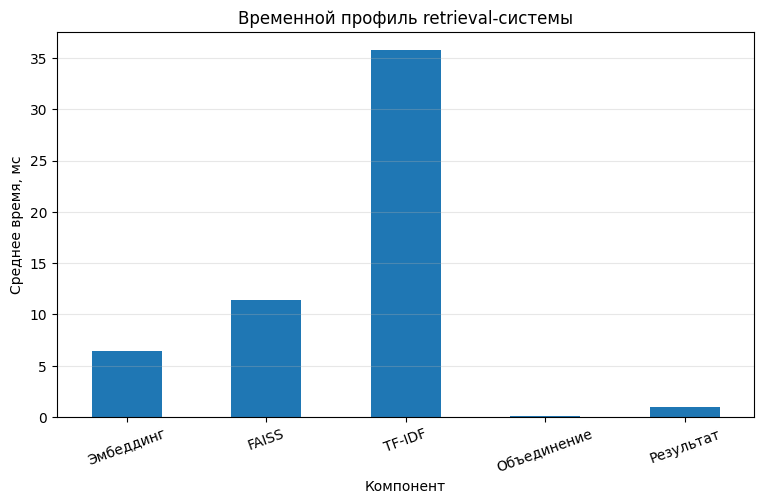

In [28]:
mean_times_ms = pd.Series(
    {
        "Эмбеддинг": (
            evaluation_df["encoding_time"].mean()
            * 1000
        ),
        "FAISS": (
            evaluation_df["faiss_time"].mean()
            * 1000
        ),
        "TF-IDF": (
            evaluation_df["tfidf_time"].mean()
            * 1000
        ),
        "Объединение": (
            evaluation_df["fusion_time"].mean()
            * 1000
        ),
        "Результат": (
            evaluation_df["formatting_time"].mean()
            * 1000
        )
    }
)

display(
    mean_times_ms.to_frame(
        "Среднее время, мс"
    )
)

plt.figure(figsize=(9, 5))

mean_times_ms.plot(kind="bar")

plt.title("Временной профиль retrieval-системы")
plt.xlabel("Компонент")
plt.ylabel("Среднее время, мс")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [29]:
def profile_reranked_search(
    query,
    top_k=5,
    rerank_k=50
):
    total_start = time.perf_counter()

    candidates, profile = profile_hybrid_search(
        query=query,
        top_k=rerank_k,
        candidate_k=max(CANDIDATE_K, rerank_k)
    )

    document_texts = (
        candidates["title"].fillna("")
        + ". "
        + candidates["abstract"].fillna("")
    ).tolist()

    pairs = [
        (str(query), document_text)
        for document_text in document_texts
    ]


    synchronize_gpu()
    start = time.perf_counter()

    reranker_scores = reranker.predict(
        pairs,
        batch_size=32,
        show_progress_bar=False
    )

    synchronize_gpu()

    profile["reranking_time"] = (
        time.perf_counter() - start
    )

    reranker_scores = np.asarray(
        reranker_scores
    )

    best_order = np.argsort(
        -reranker_scores
    )[:top_k]

    results = candidates.iloc[
        best_order
    ].copy()

    results = results.rename(
        columns={
            "rank": "hybrid_rank",
            "score": "hybrid_score"
        }
    )

    results.insert(
        0,
        "reranker_score",
        reranker_scores[best_order]
    )

    results.insert(
        0,
        "rank",
        range(1, len(results) + 1)
    )

    results = results.reset_index(drop=True)

    profile["total_time"] = (
        time.perf_counter() - total_start
    )

    return results, profile


print("Поиск с reranker создан")

Поиск с reranker создан


In [30]:
reranked_rows = []


_ = profile_reranked_search(
    test_df.iloc[0]["query"],
    top_k=5,
    rerank_k=RERANK_K
)

for row in tqdm(
    test_df.itertuples(index=False),
    total=len(test_df),
    desc="Оценка reranker"
):
    results, profile = profile_reranked_search(
        query=row.query,
        top_k=5,
        rerank_k=RERANK_K
    )

    retrieved_ids = (
        results["id"]
        .astype(str)
        .tolist()
    )

    relevant_id = str(row.id)

    correct_rank = next(
        (
            rank
            for rank, found_id in enumerate(
                retrieved_ids,
                start=1
            )
            if found_id == relevant_id
        ),
        0
    )

    rr_at_5 = (
        1.0 / correct_rank
        if correct_rank > 0
        else 0.0
    )

    reranked_rows.append(
        {
            "query": row.query,
            "relevant_id": relevant_id,
            "correct_rank": correct_rank,
            "reciprocal_rank_at_5": rr_at_5,
            "found_at_5": correct_rank > 0,
            "encoding_time": profile[
                "encoding_time"
            ],
            "faiss_time": profile[
                "faiss_time"
            ],
            "tfidf_time": profile[
                "tfidf_time"
            ],
            "fusion_time": profile[
                "fusion_time"
            ],
            "reranking_time": profile[
                "reranking_time"
            ],
            "formatting_time": profile[
                "formatting_time"
            ],
            "total_time": profile[
                "total_time"
            ]
        }
    )

reranked_evaluation_df = pd.DataFrame(
    reranked_rows
)

print(
    "Обработано запросов:",
    len(reranked_evaluation_df)
)

Оценка reranker: 100%|██████████| 1000/1000 [06:12<00:00,  2.69it/s]

Обработано запросов: 1000


In [31]:
reranked_mrr_at_5 = reranked_evaluation_df[
    "reciprocal_rank_at_5"
].mean()

reranked_found_at_5 = int(
    reranked_evaluation_df[
        "found_at_5"
    ].sum()
)

reranked_found_share = reranked_evaluation_df[
    "found_at_5"
].mean()

reranked_mean_time = reranked_evaluation_df[
    "total_time"
].mean()

print(f"Старый MRR@5: {mrr_at_5:.4f}")
print(
    f"MRR@5 после reranker: "
    f"{reranked_mrr_at_5:.4f}"
)

print(
    "Правильная статья найдена в Top-5:",
    reranked_found_at_5,
    "из",
    len(reranked_evaluation_df)
)

print(
    f"Доля найденных статей: "
    f"{reranked_found_share:.4f}"
)

print(
    f"Среднее время запроса: "
    f"{reranked_mean_time:.4f} сек."
)

if reranked_mrr_at_5 > 0.91:
    print(
        "\nЦелевое качество достигнуто: "
        "проект проходит"
    )
else:
    print(
        "\nЦелевое качество пока "
        "не достигнуто"
    )

reranked_evaluation_df.to_csv(
    PROJECT_DIR
    / "reranked_evaluation_results.csv",
    index=False
)

Старый MRR@5: 0.8708
MRR@5 после reranker: 0.9375
Правильная статья найдена в Top-5: 976 из 1000
Доля найденных статей: 0.9760
Среднее время запроса: 0.3712 сек.

Целевое качество достигнуто: проект проходит


,"Среднее время, мс"
Создание эмбеддинга,6.726441
Поиск FAISS,11.516098
Поиск TF-IDF,33.730578
Объединение результатов,0.127392
Reranker,315.873460
Формирование результата,1.072177


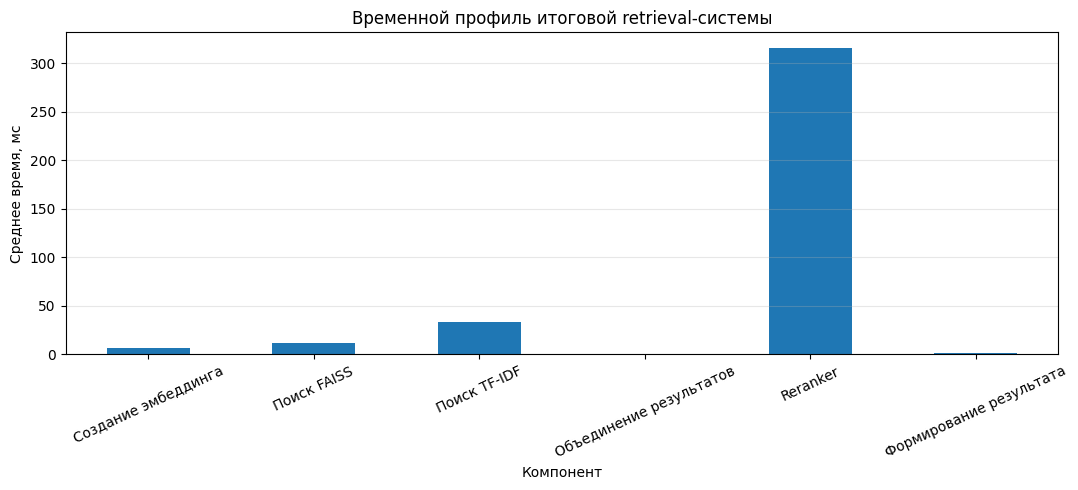

Среднее полное время одного запроса: 0.3712 сек.


In [32]:
final_profile_ms = pd.Series(
    {
        "Создание эмбеддинга": (
            reranked_evaluation_df["encoding_time"].mean()
            * 1000
        ),
        "Поиск FAISS": (
            reranked_evaluation_df["faiss_time"].mean()
            * 1000
        ),
        "Поиск TF-IDF": (
            reranked_evaluation_df["tfidf_time"].mean()
            * 1000
        ),
        "Объединение результатов": (
            reranked_evaluation_df["fusion_time"].mean()
            * 1000
        ),
        "Reranker": (
            reranked_evaluation_df["reranking_time"].mean()
            * 1000
        ),
        "Формирование результата": (
            reranked_evaluation_df["formatting_time"].mean()
            * 1000
        )
    }
)

display(
    final_profile_ms.to_frame(
        "Среднее время, мс"
    )
)

plt.figure(figsize=(11, 5))

final_profile_ms.plot(kind="bar")

plt.title(
    "Временной профиль итоговой retrieval-системы"
)
plt.xlabel("Компонент")
plt.ylabel("Среднее время, мс")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "Среднее полное время одного запроса:",
    round(
        reranked_evaluation_df["total_time"].mean(),
        4
    ),
    "сек."
)

Вывод по этапу 3

Для оценки retrieval-системы был выполнен поиск по всем 1000 тестовым запросам. Сначала использовался гибридный поиск, объединяющий семантический поиск FAISS и лексический поиск TF-IDF. Его результат составил MRR@5 = 0.8708, что было ниже целевого значения.

После добавления reranker качество выросло до MRR@5 = 0.9375. Правильная статья попала в первые пять результатов для 976 из 1000 запросов. Таким образом, целевое значение MRR@5 > 0.91 достигнуто, и проект проходит по качеству.

Среднее время обработки одного запроса составило 0.3726 секунды. Увеличение времени связано с работой reranker, который дополнительно сравнивает запрос с найденными статьями и улучшает их порядок в поисковой выдаче.

Обший вывод (4 ЭТАП)

В проекте была построена retrieval-система для поиска статей arXiv. Система сочетает три подхода: семантический поиск FAISS, лексический поиск TF-IDF и повторное ранжирование найденных документов с помощью CrossEncoder.

Главным улучшением стало добавление reranker. Он повысил MRR@5 с 0.8708 до 0.9375, но одновременно увеличил время обработки запроса. Таким образом, основным узким местом итоговой системы является повторное ранжирование кандидатов.

Для дальнейшего ускорения можно уменьшить количество документов, передаваемых в reranker, использовать более компактную модель, обрабатывать пары батчами или применять оптимизацию модели. Эмбеддинги статей и поисковые индексы сохраняются заранее, поэтому их не требуется создавать заново при каждом запуске.

